In [1]:
!pip -q install -U langgraph langchain langchain-google-genai tavily-python requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.9/147.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from getpass import getpass

def get_key(name, prompt):
    value = os.getenv(name)
    if not value:
        value = getpass(prompt)
    os.environ[name] = value
    return value

GOOGLE_API_KEY = get_key("GOOGL
E_API_KEY", "Gemini API key: ")
AVIATIONSTACK_KEY = get_key("AVIATIONSTACK_KEY", "Aviationstack access key: ")
NEWSDATA_API_KEY = get_key("NEWSDATA_API_KEY", "NewsData.io API key: ")
TAVILY_API_KEY = get_key("TAVILY_API_KEY", "Tavily API key: ")
OPENWEATHER_API_KEY = get_key("OPENWEATHER_API_KEY", "OpenWeather API key: ")

print("API keys loaded.")

Gemini API key: ··········
Aviationstack access key: ··········
NewsData.io API key: ··········
Tavily API key: ··········
OpenWeather API key: ··········
API keys loaded.


In [3]:
import json
import requests
from typing import TypedDict, List, Dict, Any

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from tavily import TavilyClient

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0.2,
    google_api_key=GOOGLE_API_KEY
)

tavily = TavilyClient(api_key=TAVILY_API_KEY)

print("Gemini + Tavily initialized.")

Gemini + Tavily initialized.


#shared langgraph state

In [4]:
class TravelState(TypedDict, total=False):
    user_request: str

    origin: str
    destination: str
    origin_iata: str
    destination_iata: str
    start_date: str
    end_date: str
    days: int
    travelers: int
    preferences: str

    flights: Dict[str, Any]
    hotels: Dict[str, Any]
    news: Dict[str, Any]
    weather: Dict[str, Any]
    cost_research: Dict[str, Any]
    cost: Dict[str, Any]

    itinerary: str
    final_answer: str

#Supervisor agent
Extract origin , destination , dates, no. of travellers

In [5]:
def supervisor_agent(state: TravelState):

    prompt = f"""
You are the supervisor of a real-time travel multi-agent system.

Extract structured travel requirements from the user's request.

Return ONLY valid JSON.
Do not use markdown.
Do not use ```json.

Format:

{{
  "origin": "city or airport",
  "destination": "city or airport",
  "origin_iata": "IATA code if confidently known, otherwise empty string",
  "destination_iata": "IATA code if confidently known, otherwise empty string",
  "start_date": "YYYY-MM-DD or empty string",
  "end_date": "YYYY-MM-DD or empty string",
  "days": 5,
  "travelers": 2,
  "preferences": "travel preferences"
}}

Do not invent IATA codes.

User request:
{state["user_request"]}
"""

    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    # Gemini may return content as a string OR a list of content blocks
    content = response.content

    if isinstance(content, list):
        text_parts = []

        for item in content:
            if isinstance(item, str):
                text_parts.append(item)

            elif isinstance(item, dict):
                if "text" in item:
                    text_parts.append(item["text"])

        content = "".join(text_parts)

    raw = content.strip()

    # Remove markdown fences if Gemini adds them
    raw = raw.replace("```json", "").replace("```", "").strip()

    print("SUPERVISOR RESPONSE:")
    print(raw)

    data = json.loads(raw)

    return data

#Test

In [15]:
test_state = {
    "user_request": "I want to travel from Delhi to Goa from 10 September 2026 to 15 September 2026 for 2 people. I prefer budget hotels."
}

result = supervisor_agent(test_state)

print("\nFINAL RESULT:")
print(result)

SUPERVISOR RESPONSE:
{
  "origin": "Delhi",
  "destination": "Goa",
  "origin_iata": "DEL",
  "destination_iata": "GOI",
  "start_date": "2026-09-10",
  "end_date": "2026-09-15",
  "days": 5,
  "travelers": 2,
  "preferences": "budget hotels"
}

FINAL RESULT:
{'origin': 'Delhi', 'destination': 'Goa', 'origin_iata': 'DEL', 'destination_iata': 'GOI', 'start_date': '2026-09-10', 'end_date': '2026-09-15', 'days': 5, 'travelers': 2, 'preferences': 'budget hotels'}


#Travel agent - Aviationstack

In [7]:
def aviationstack_get(params):
    url = "https://api.aviationstack.com/v1/flights"
    params = dict(params)
    params["access_key"] = AVIATIONSTACK_KEY

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    if data.get("error"):
        raise RuntimeError(data["error"])

    return data


def flight_agent(state: TravelState):
    params = {"limit": 20}

    if state.get("origin_iata"):
        params["dep_iata"] = state["origin_iata"]

    if state.get("destination_iata"):
        params["arr_iata"] = state["destination_iata"]

    if state.get("start_date"):
        params["flight_date"] = state["start_date"]

    data = aviationstack_get(params)

    return {
        "flights": {
            "source": "Aviationstack",
            "query": params,
            "results": data.get("data", []),
            "pagination": data.get("pagination", {})
        }
    }

#Test the aviationstack directly

In [8]:
# Test Aviationstack directly

test_params = {
    "limit": 5
}

data = aviationstack_get(test_params)

print("✅ Aviationstack API is working")
print("Number of flights returned:", len(data.get("data", [])))

print("\nFirst flight:")
if data.get("data"):
    print(data["data"][0])
else:
    print("No flight data returned")

✅ Aviationstack API is working
Number of flights returned: 5

First flight:
{'flight_date': '2026-08-28', 'flight_status': 'scheduled', 'departure': {'airport': 'N?djili International', 'timezone': 'Africa/Kinshasa', 'iata': 'FIH', 'icao': 'FZAA', 'terminal': None, 'gate': None, 'delay': None, 'scheduled': '2026-08-28T00:55:00+00:00', 'estimated': '2026-08-28T00:55:00+00:00', 'actual': None, 'estimated_runway': None, 'actual_runway': None}, 'arrival': {'airport': 'Bole International', 'timezone': 'Africa/Addis_Ababa', 'iata': 'ADD', 'icao': 'HAAB', 'terminal': '2', 'gate': 'A10', 'baggage': None, 'scheduled': '2026-08-28T07:35:00+00:00', 'delay': None, 'estimated': None, 'actual': None, 'estimated_runway': None, 'actual_runway': None}, 'airline': {'name': 'Ethiopian Airlines', 'iata': 'ET', 'icao': 'ETH'}, 'flight': {'number': '842', 'iata': 'ET842', 'icao': 'ETH842', 'codeshared': None}, 'aircraft': {'registration': None, 'iata': None, 'icao': None, 'icao24': '040169'}, 'live': None}


#HOTEL AGENT

In [9]:
def hotel_agent(state: TravelState):
    destination = state["destination"]

    query = f'''
best hotels in {destination}
hotel prices reviews availability
for a {state.get("days", 1)} day trip
'''.strip()

    response = tavily.search(
        query,
        search_depth="advanced",
        max_results=8,
        include_answer=True
    )

    return {
        "hotels": {
            "source": "Tavily",
            "query": query,
            "answer": response.get("answer"),
            "results": response.get("results", [])
        }
    }

In [10]:
import pprint

# Create a small test State for the Hotel Agent
test_state = {
    "destination": "Manali",
    "days": 5
}

# Execute the Hotel Agent
hotel_result = hotel_agent(test_state)

print("========== HOTEL AGENT TEST ==========")

print("\nSource:")
print(hotel_result["hotels"]["source"])

print("\nQuery sent to Tavily:")
print(hotel_result["hotels"]["query"])

print("\nTavily Answer:")
print(hotel_result["hotels"]["answer"])

print("\nNumber of search results:")
print(len(hotel_result["hotels"]["results"]))

print("\nSearch Results:")
pprint.pp(hotel_result["hotels"]["results"])

========== HOTEL AGENT TEST ==========

Source:
Tavily

Query sent to Tavily:
best hotels in Manali
hotel prices reviews availability
for a 5 day trip

Tavily Answer:
Best hotels in Manali for a 5-day trip: The Himalayan, LN Grand Premium & Luxury Suites, and The Johnson's Lodge & Spa. Prices range from $30 to $400 per night. Check availability for current rates.

Number of search results:
8

Search Results:
[{'url': 'https://www.kayak.com/Manali-Hotels.45718.hotel.ksp',
  'title': '16 Best Hotels in Manali. Hotels from $6/night - KAYAK',
  'content': 'These are the best prices for Aug 30 - 31.\n'
             '\n'
             'Hotel class\n'
             '\n'
             'Review Score\n'
             '\n'
             'Snow Valley Resorts - Manali - Bedroom\n'
             '\n'
             'Snow Valley Resorts - Manali - Bedroom\n'
             '\n'
             'Snow Valley Resorts\n'
             '\n'
             'Manali, HP, India\n'
             '\n'
             '8.9Very good

#News agent

In [11]:
def news_agent(state: TravelState):
    destination = state["destination"]

    params = {
        "apikey": NEWSDATA_API_KEY,
        "q": destination,
        "language": "en",
        "removeduplicate": 1,
        "size": 10
    }

    response = requests.get(
        "https://newsdata.io/api/1/latest",
        params=params,
        timeout=30
    )
    response.raise_for_status()
    data = response.json()

    if data.get("status") == "error":
        raise RuntimeError(data)

    return {
        "news": {
            "source": "NewsData.io",
            "query": destination,
            "results": data.get("results", []),
            "nextPage": data.get("nextPage")
        }
    }

In [12]:
import pprint

# Create a small test State for the News Agent
test_state = {
    "destination": "india"
}

# Execute the News Agent
news_result = news_agent(test_state)

print("========== NEWS AGENT TEST ==========")

print("\nSource:")
print(news_result["news"]["source"])

print("\nQuery sent to NewsData.io:")
print(news_result["news"]["query"])

print("\nNumber of news articles:")
print(len(news_result["news"]["results"]))

print("\nNews Results:")
pprint.pp(news_result["news"]["results"])

========== NEWS AGENT TEST ==========

Source:
NewsData.io

Query sent to NewsData.io:
india

Number of news articles:
10

News Results:
[{'article_id': '84afc93d2b7f9d32002cfe19b3377683',
  'link': 'https://www.emirates247.com/world/devastating-himalaya-flood-rising-death-toll-nearly-1500-missing/4950',
  'title': 'Devastating Himalaya flood: Rising death toll, nearly 1,500 '
           'missing',
  'description': 'TRISHULI, Nepal/BEIJING: Nearly 1,500 people including at '
                 "least 800 foreigners are missing across Nepal and China's "
                 '\u200cTibet, authorities said on Thursday, after a wall of '
                 'mud and rock collapsed into a Himalayan river, sending '
                 'catastrophic floods through towns and valleys. Rescuers in '
                 'Nepal used helicopters to search for survivors and drop '
                 "emergency supplies to thousands cut off after Wednesday's "
                 'disaster swept a rugged mountainous r

#Weather agent

In [13]:
def weather_agent(state: TravelState):
    destination = state["destination"]

    # OpenWeather Geocoding API
    geo_response = requests.get(
        "https://api.openweathermap.org/geo/1.0/direct",
        params={
            "q": destination,
            "limit": 1,
            "appid": OPENWEATHER_API_KEY
        },
        timeout=30
    )
    geo_response.raise_for_status()
    locations = geo_response.json()

    if not locations:
        raise RuntimeError(f"Could not geocode destination: {destination}")

    location = locations[0]
    lat = location["lat"]
    lon = location["lon"]

    # Current weather API
    weather_response = requests.get(
        "https://api.openweathermap.org/data/2.5/weather",
        params={
            "lat": lat,
            "lon": lon,
            "appid": OPENWEATHER_API_KEY,
            "units": "metric"
        },
        timeout=30
    )
    weather_response.raise_for_status()

    weather = weather_response.json()

    return {
        "weather": {
            "source": "OpenWeather",
            "location": location,
            "current": weather
        }
    }

In [14]:
import pprint

# Create a small test State for the Weather Agent
test_state = {
    "destination": "Manali"
}

# Execute the Weather Agent
weather_result = weather_agent(test_state)

print("========== WEATHER AGENT TEST ==========")

print("\nSource:")
print(weather_result["weather"]["source"])

print("\nLocation found:")
pprint.pp(weather_result["weather"]["location"])

print("\nCurrent Weather:")
pprint.pp(weather_result["weather"]["current"])

========== WEATHER AGENT TEST ==========

Source:
OpenWeather

Location found:
{'name': 'Manali',
 'local_names': {'ml': 'മണാലി',
                 'ta': 'மணாலி',
                 'en': 'Manali',
                 'ru': 'Манали',
                 'ja': 'マナリ',
                 'kn': 'ಮನಾಲಿ',
                 'he': 'מנאלי',
                 'hi': 'मनाली'},
 'lat': 32.2454608,
 'lon': 77.1872926,
 'country': 'IN',
 'state': 'Himachal Pradesh'}

Current Weather:
{'coord': {'lon': 77.1873, 'lat': 32.2455},
 'weather': [{'id': 803,
              'main': 'Clouds',
              'description': 'broken clouds',
              'icon': '04n'}],
 'base': 'stations',
 'main': {'temp': 17.32,
          'feels_like': 17.22,
          'temp_min': 17.32,
          'temp_max': 17.32,
          'pressure': 1014,
          'humidity': 81,
          'sea_level': 1014,
          'grnd_level': 661},
 'visibility': 10000,
 'wind': {'speed': 0.68, 'deg': 73, 'gust': 1},
 'clouds': {'all': 68},
 'dt': 1787851611,


#cost agent

In [16]:
def cost_agent(state: TravelState):
    destination = state["destination"]
    days = state.get("days", 1)
    travelers = state.get("travelers", 1)

    query = f'''
current travel cost for {destination}
hotel price per night
local taxi transport cost
tourist attraction ticket prices
food cost per person
activities and sightseeing costs
for {days} days and {travelers} travelers
'''.strip()

    research = tavily.search(
        query,
        search_depth="advanced",
        max_results=10,
        include_answer=True
    )

    synthesis_prompt = f'''
You are the Cost Agent in a travel multi-agent system.

Estimate the trip cost using ONLY information available in the retrieved research.

Destination: {destination}
Days: {days}
Travelers: {travelers}

Hotel research:
{state.get("hotels", {})}

Additional live cost research:
{research}

Flight/aviation data:
{state.get("flights", {})}

Return JSON:
{{
  "hotel_cost": "...",
  "transport_cost": "...",
  "food_cost": "...",
  "activities_cost": "...",
  "flight_cost": "unknown unless a real fare was actually found",
  "total_estimate": "...",
  "currency": "INR",
  "assumptions": ["..."],
  "source_notes": ["..."]
}}

Never fabricate a price.
If a price is unavailable, say "not available from retrieved sources".
'''

    response = llm.invoke([HumanMessage(content=synthesis_prompt)])

    return {
        "cost_research": research,
        "cost": {
            "source": "Tavily + Gemini synthesis",
            "research": research,
            "estimate": response.content
        }
    }

In [17]:
import pprint

# Create a test State for the Cost Agent
test_state = {
    "destination": "Manali",
    "days": 5,
    "travelers": 2,

    "hotels": {
        "source": "Tavily",
        "results": [
            {
                "title": "Sample hotel research",
                "content": "Hotel prices vary depending on season and hotel category."
            }
        ]
    },

    "flights": {
        "source": "Aviationstack",
        "results": []
    }
}

# Execute the Cost Agent
cost_result = cost_agent(test_state)

print("========== COST AGENT TEST ==========")

print("\nCost Research:")
pprint.pp(cost_result.get("cost_research"))

print("\nCost Result:")
pprint.pp(cost_result.get("cost"))

========== COST AGENT TEST ==========

Cost Research:
{'query': 'current travel cost for Manali\n'
          'hotel price per night\n'
          'local taxi transport cost\n'
          'tourist attraction ticket prices\n'
          'food cost per person\n'
          'activities and sightseeing costs\n'
          'for 5 days and 2 travelers',
 'follow_up_questions': None,
 'answer': 'For a 5-day trip to Manali for 2 travelers, expect hotel costs '
           '₹1,600-₹7,000 per night, local transport ₹1,000-₹3,000 per day, '
           'and food ₹800-₹2,400 per day.',
 'images': [],
 'results': [{'url': 'https://www.mintoholidays.com/blog/manali-trip-cost-budget-guide',
              'title': 'Manali Trip Cost: Complete Budget Guide for 4-6 Days',
              'content': 'Budget stay: ₹800-₹1,500 per person per night\n'
                         ' Mid-range hotel: ₹1,500-₹3,500 per room per night\n'
                         ' Premium hotel or resort: ₹4,000-₹10,000+ per room '
          

In [18]:
#Initnary agent
def itinerary_agent(state: TravelState):
    prompt = f'''
You are the Itinerary Agent.

Create a practical {state.get("days", 1)}-day itinerary.

Trip:
{state["origin"]} -> {state["destination"]}

Travelers: {state.get("travelers", 1)}
Dates: {state.get("start_date", "")} to {state.get("end_date", "")}
Preferences: {state.get("preferences", "")}

LIVE FLIGHT DATA:
{state.get("flights", {})}

LIVE HOTEL RESEARCH:
{state.get("hotels", {})}

CURRENT WEATHER:
{state.get("weather", {})}

CURRENT NEWS:
{state.get("news", {})}

LIVE COST RESEARCH:
{state.get("cost", {})}

Rules:
1. Do not invent live facts.
2. Do not claim a hotel is available unless the source says so.
3. Do not claim a flight is bookable.
4. Make the plan weather-aware.
5. Use current news to flag relevant travel disruptions or events.
6. Keep the itinerary realistic geographically.
7. Clearly mark anything that is an estimate.

Return:
- recommended travel approach
- hotel shortlist
- day-by-day itinerary
- weather considerations
- current travel/news alerts
- estimated budget
- assumptions
'''

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"itinerary": response.content}

#final agent

In [19]:
def final_agent(state: TravelState):

    print("🎯 FINAL AGENT STARTED")

    prompt = f"""
You are the final travel assistant.

Create the final travel plan using the information
collected by the other agents.

USER REQUEST:
{state.get("user_request", "")}

FLIGHTS:
{state.get("flights", {})}

HOTELS:
{state.get("hotels", {})}

NEWS:
{state.get("news", {})}

WEATHER:
{state.get("weather", {})}

COST:
{state.get("cost", {})}

ITINERARY:
{state.get("itinerary", "")}

Create a final travel plan containing:

✈️ Flight information
🏨 Hotel recommendations
🌤️ Weather
📰 Important news
💰 Estimated cost
🗺️ Day-by-day itinerary

Important:
- Do not invent information.
- Do not invent prices.
- Clearly mention estimates.
- Use the information provided by the agents.
"""

    print("🤖 Calling Gemini...")

    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    print("🤖 Gemini response received")

    content = response.content

    # Gemini can return string OR list
    if isinstance(content, list):

        text = ""

        for item in content:

            if isinstance(item, str):
                text += item

            elif isinstance(item, dict):
                if "text" in item:
                    text += item["text"]

        content = text

    print("🎯 FINAL AGENT COMPLETED")

    return {
        "final_answer": content
    }

In [20]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TravelState)

builder.add_node("supervisor", supervisor_agent)
builder.add_node("flight_agent", flight_agent)
builder.add_node("hotel_agent", hotel_agent)
builder.add_node("news_agent", news_agent)
builder.add_node("weather_agent", weather_agent)
builder.add_node("cost_agent", cost_agent)
builder.add_node("itinerary_agent", itinerary_agent)
builder.add_node("final_agent", final_agent)

# Start
builder.add_edge(START, "supervisor")

# Supervisor → specialist agents
builder.add_edge("supervisor", "flight_agent")
builder.add_edge("supervisor", "hotel_agent")
builder.add_edge("supervisor", "news_agent")
builder.add_edge("supervisor", "weather_agent")

# Flight + Hotel → Cost
builder.add_edge("flight_agent", "cost_agent")
builder.add_edge("hotel_agent", "cost_agent")

# All research → Itinerary
builder.add_edge("flight_agent", "itinerary_agent")
builder.add_edge("hotel_agent", "itinerary_agent")
builder.add_edge("news_agent", "itinerary_agent")
builder.add_edge("weather_agent", "itinerary_agent")
builder.add_edge("cost_agent", "itinerary_agent")

# Itinerary → Final
builder.add_edge("itinerary_agent", "final_agent")

# Final → End
builder.add_edge("final_agent", END)

# IMPORTANT: compile again
graph = builder.compile()

print("✅ Graph rebuilt successfully")

✅ Graph rebuilt successfully


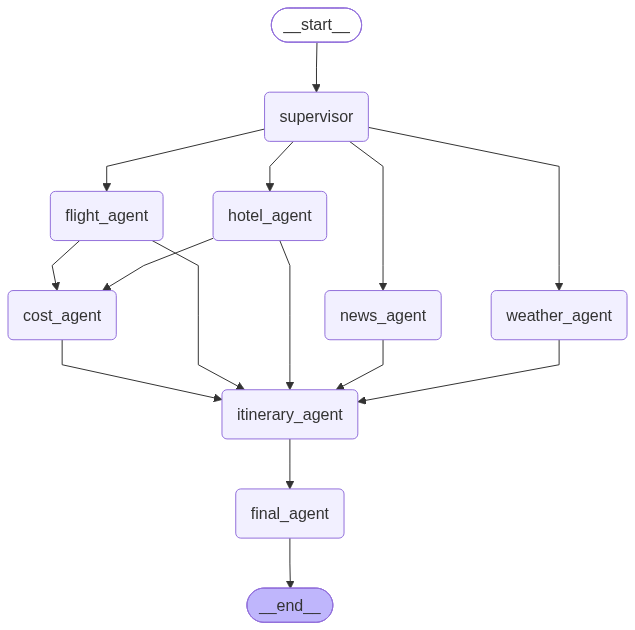

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [22]:
user_request = '''
Plan a 5-day trip from Delhi to Manali for 2 travelers.
I want comfortable hotels, scenic places, local food and a moderate budget.
Use current flight information, current hotel information, current weather,
recent news and current travel costs. Then create a day-by-day itinerary.
'''

result = graph.invoke({
    "user_request": user_request
})

print(result["final_answer"])

SUPERVISOR RESPONSE:
{
  "origin": "Delhi",
  "destination": "Manali",
  "origin_iata": "DEL",
  "destination_iata": "",
  "start_date": "",
  "end_date": "",
  "days": 5,
  "travelers": 2,
  "preferences": "comfortable hotels, scenic places, local food, moderate budget"
}
🎯 FINAL AGENT STARTED
🤖 Calling Gemini...
🤖 Gemini response received
🎯 FINAL AGENT COMPLETED
🎯 FINAL AGENT STARTED
🤖 Calling Gemini...
🤖 Gemini response received
🎯 FINAL AGENT COMPLETED
Here is your comprehensive, data-backed 5-day travel plan for 2 travelers journeying from Delhi to Manali. This plan is compiled using the latest flight, hotel, weather, cost, and safety news collected by our specialized agents.

---

### ✈️ Flight & Transit Information

**Flight Availability Note:** 
Based on current flight data from Aviationstack, there are **no direct flights** operating from Delhi (DEL) to Kullu/Bhuntar Airport (the closest airport to Manali). The provided flight data only contains routes to other destinations (su